# Tarea 2
**Grupo 4  Camila Contreras - Christian Pérez - Javier Uribe**
Curso 4 - Diplomado en Inteligencia Artificial para el Diagnóstico Médico

## Clasificación de señales de ECG

El objetivo de esta tarea es detectar si es que latidos medidos en electrocardiograma son normales o no. Los datos vienen originalmente del Physionet's MIT-BIH Arrhythmia Dataset.

Cada dato está clasificado en una de las cinco categorías:

- 0: Normal
- 1: Latido anormal supraventricular
- 2: Latido anormal ventricular
- 3: Latidos fusionados
- 4: No clasificable

Cada ejemplo es una traza de ECG de un canal, que comienza en R y continúa hasta finalizar el siguiente complejo QRS. Se rellena con ceros si es que se ocupan menos de las 187 posiciones disponibles.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
import kagglehub

path = kagglehub.dataset_download('shayanfazeli/heartbeat')

Using Colab cache for faster access to the 'heartbeat' dataset.


In [ ]:
# esto se demora unos 30 segundos
data_train = np.genfromtxt(path + '/mitbih_train.csv', delimiter=',')
data_test = np.genfromtxt(path + '/mitbih_test.csv', delimiter=',')

In [ ]:
X_train = data_train[:, :-1]
y_train = data_train[:, -1]

# para probar sus algoritmos, puede considerar un subset de los datos.
# Pero el entrenamiento final tiene que ser con todos los datos
# N = 10_000
# X_train = data_train[:N, :-1]
# y_train = data_train[:N, -1]


X_test = data_test[:, :-1]
y_test = data_test[:, -1]

print(X_train.shape)

(87554, 187)


## Ejercicio 1

- Grafique 5 señales de ejemplo del set de entrenamiento
- Calcule la distrubución de las clases en el set de entrenamiento
- Implemente una estrategia para alivear el desbalance de clases.
- Defina los `Dataset` y `DataLoader` de `torch` para el set de entrenamiento y testeo.



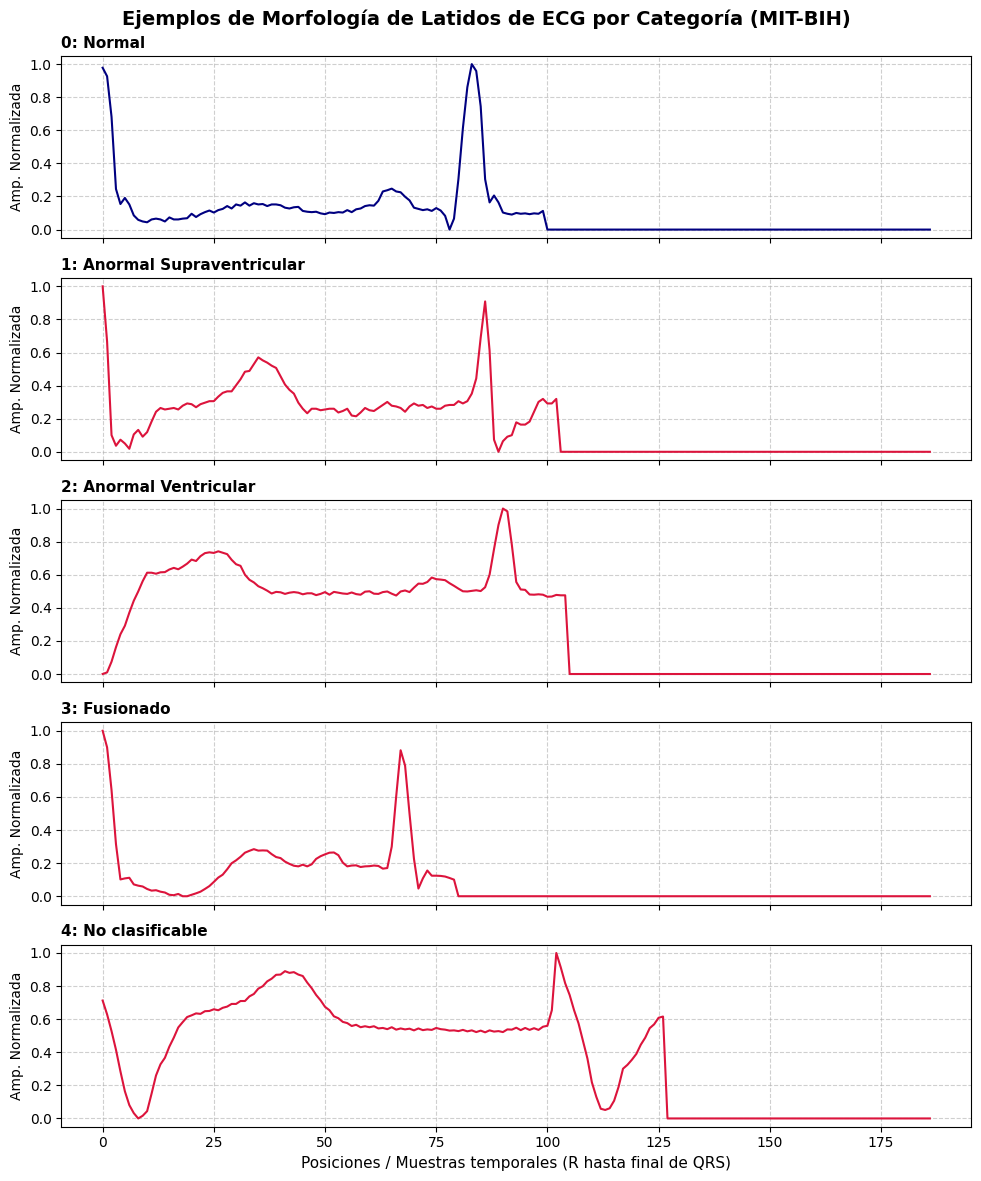

In [ ]:
#Grafique 5 señales de ejemplo del set de entrenamiento
import matplotlib.pyplot as plt
import numpy as np

# 1. Separar las características (X) de las etiquetas (y)
X_train = data_train[:, :-1]  # Las primeras 187 columnas
y_train = data_train[:, -1]   # La última columna (0.0 a 4.0)

# Diccionario para mapear los números a nombres legibles clínicos
clases_map = {
    0: "0: Normal",
    1: "1: Anormal Supraventricular",
    2: "2: Anormal Ventricular",
    3: "3: Fusionado",
    4: "4: No clasificable"
}

# 2. Configurar la figura de Matplotlib (5 subgráficos en una columna)
fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=True, sharey=True)
fig.suptitle('Ejemplos de Morfología de Latidos de ECG por Categoría (MIT-BIH)', fontsize=14, fontweight='bold')

# 3. Iterar sobre cada clase para buscar un ejemplo y graficarlo
for i in range(5):
    # Encontrar los índices de las filas que pertenecen a la clase i
    indices_clase = np.where(y_train == i)[0]

    # Tomar el primer ejemplo disponible de esa clase
    primer_ejemplo_idx = indices_clase[0]
    senal = X_train[primer_ejemplo_idx]

    # Graficar la señal en su respectivo subgráfico
    axes[i].plot(senal, color='crimson' if i != 0 else 'navy', lw=1.5)
    axes[i].set_title(clases_map[i], fontsize=11, loc='left', fontweight='semibold')
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].set_ylabel('Amp. Normalizada')

# Configuración del eje X final (tiempo/muestras)
axes[-1].set_xlabel('Posiciones / Muestras temporales (R hasta final de QRS)', fontsize=11)

plt.tight_layout()
plt.show()

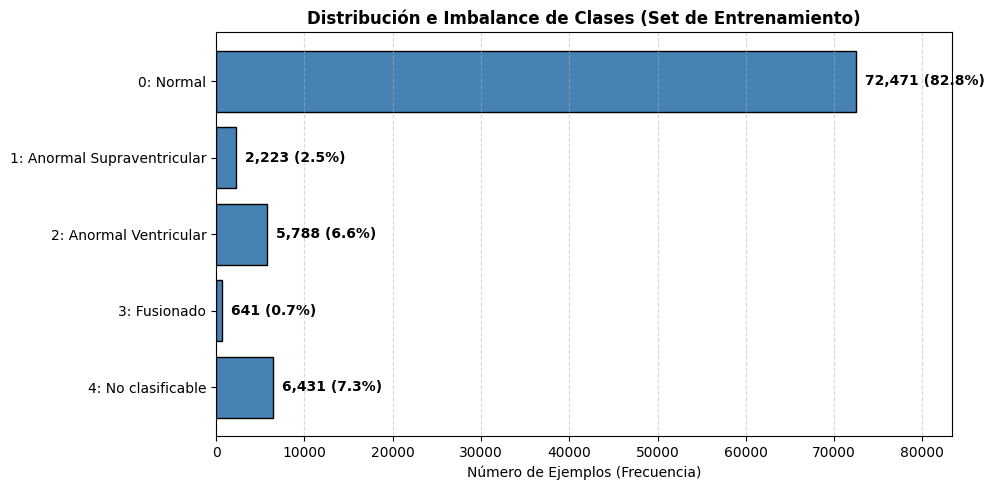

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calcular la frecuencia de cada clase
frecuencia = np.bincount(y_train.astype(int))

# Crear las etiquetas para el gráfico usando el diccionario clases_map
# Aseguramos que las etiquetas correspondan a las clases presentes y a sus nombres clínicos
plot_labels = [clases_map[i] for i in sorted(clases_map.keys())]

# Calcular proporciones
porcentajes = (frecuencia / len(y_train)) * 100

# Configurar gráfico horizontal
plt.figure(figsize=(10, 5))
barras = plt.barh(plot_labels, frecuencia, color='steelblue', edgecolor='black')

# Añadir los porcentajes y totales al final de cada barra para mayor claridad
for barra, porcentaje, total in zip(barras, porcentajes, frecuencia):
    ancho = barra.get_width()
    plt.text(ancho + 1000, barra.get_y() + barra.get_height()/2,
             f'{total:,} ({porcentaje:.1f}%)',
             va='center', ha='left', fontsize=10, fontweight='bold')

plt.title('Distribución e Imbalance de Clases (Set de Entrenamiento)', fontsize=12, fontweight='bold')
plt.xlabel('Número de Ejemplos (Frecuencia)')
plt.xlim(0, max(frecuencia) * 1.15) # Dar espacio a las etiquetas de texto
plt.gca().invert_yaxis() # Poner la clase 0 arriba
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
#Implemente una estrategia para alivear el desbalance de clases.
from imblearn.over_sampling import RandomOverSampler
import numpy as np

# 1. Preparar los datos originales de entrenamiento
X_train = data_train[:, :-1]
y_train = data_train[:, -1]

# 2. Preparar los datos de prueba (estos NO se balancean)
X_test = data_test[:, :-1]
y_test = data_test[:, -1]

print(f"Estructura original de X_train: {X_train.shape}")
print(f"Distribución original de clases en train: {np.bincount(y_train.astype(int))}")
print("-" * 50)

# 3. Inicializar el RandomOverSampler
# 'not majority' balancea todas las clases para que tengan el mismo número que la clase mayoritaria
ros = RandomOverSampler(sampling_strategy='not majority', random_state=42)

# 4. Ajustar y aplicar el sobremuestreo a los datos de entrenamiento
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

print(f"Nueva estructura de X_train resampled: {X_train_resampled.shape}")
print(f"Nueva distribución de clases en train: {np.bincount(y_train_resampled.astype(int))}")

Estructura original de X_train: (87554, 187)
Distribución original de clases en train: [72471  2223  5788   641  6431]
--------------------------------------------------
Nueva estructura de X_train resampled: (362355, 187)
Nueva distribución de clases en train: [72471 72471 72471 72471 72471]


In [ ]:
#Defina los Dataset y DataLoader de torch para el set de entrenamiento y testeo.
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Definición del Dataset Personalizado
class ECGDataset(Dataset):
    def __init__(self, X, y):
        # Convertimos los datos a tensores de PyTorch con el tipo de dato correcto
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 2. Instanciar los Datasets
# Usamos los datos balanceados para el entrenamiento y los originales para el testeo
train_dataset = ECGDataset(X_train_resampled, y_train_resampled)
test_dataset = ECGDataset(X_test, y_test)

# 3. Definir los DataLoaders
# Definimos un tamaño de lote (Batch Size) estándar para entrenamiento de señales
BATCH_SIZE = 64

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,          # Mezclar es crítico para que el gradiente no se sesgue
    drop_last=False        # Mantener el último lote aunque sea más pequeño
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,         # No es necesario mezclar los datos de validación/test
    drop_last=False
)

# 4. Verificación rápida de las dimensiones
X_batch, y_batch = next(iter(train_loader))
print(f"Dimensiones del lote de características (X): {X_batch.shape}")
print(f"Dimensiones del lote de etiquetas (y): {y_batch.shape}")

Dimensiones del lote de características (X): torch.Size([64, 187])
Dimensiones del lote de etiquetas (y): torch.Size([64])


## Ejercicio 2

- Implemente un clasificador basado en la arquitectura LSTM vista en clases
- Entrene el clasificador
- Obtenga métricas de performance que tomen en cuenta el desbalance de clases

In [ ]:
#Implemente un clasificador basado en la arquitectura LSTM vista en clases
import torch
import torch.nn as nn
import torch.optim as optim

class ECGLSTMClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, num_classes=5, bidirectional=True):
        super(ECGLSTMClassifier, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # Capa LSTM
        # batch_first=True significa que el input tendrá la forma [64, 187, 1]
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.2 if num_layers > 1 else 0.0
        )

        # Capa Totalmente Conectada (Fully Connected) para la clasificación final
        # Si es bidireccional, el tamaño de la salida de la LSTM se duplica
        self.fc = nn.Linear(hidden_size * self.num_directions, num_classes)

    def forward(self, x):
        # x original: [64, 187] -> Añadimos la dimensión de características: [64, 187, 1]
        if x.dim() == 2:
            x = x.unsqueeze(-1)

        # out contiene la salida de la LSTM para cada paso de tiempo: [64, 187, hidden_size * num_directions]
        # _ contiene los estados ocultos (h_n, c_n) del último paso
        out, (h_n, c_n) = self.lstm(x)

        # Tomamos únicamente la salida del ÚLTIMO paso de tiempo (index 187 de la secuencia)
        # out[:, -1, :] extrae el vector final para cada elemento del lote
        last_time_step = out[:, -1, :]

        # Clasificamos a las 5 categorías de arritmias
        logits = self.fc(last_time_step)
        return logits

# Instanciar el modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo_lstm = ECGLSTMClassifier(input_size=1, hidden_size=64, num_layers=2, num_classes=5, bidirectional=True).to(device)
print(modelo_lstm)

ECGLSTMClassifier(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (fc): Linear(in_features=128, out_features=5, bias=True)
)


In [ ]:
#Entrene el clasificador
criterio = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo_lstm.parameters(), lr=0.001)
NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    # --- FASE DE ENTRENAMIENTO ---
    modelo_lstm.train()
    running_loss = 0.0
    correctas_train = 0
    total_train = 0

    for X_batch, y_batch in train_loader:
        # Enviar datos al hardware disponible (CPU o GPU)
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # 1. Resetear los gradientes acumulados
        optimizador.zero_grad()

        # 2. Forward pass (Predicción)
        predicciones = modelo_lstm(X_batch)

        # 3. Calcular la pérdida
        loss = criterio(predicciones, y_batch)

        # 4. Backward pass (Calcular gradientes)
        loss.backward()

        # 5. Actualizar los pesos de la red
        optimizador.step()

        # Métricas de entrenamiento
        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(predicciones, 1)
        total_train += y_batch.size(0)
        correctas_train += (predicted == y_batch).sum().item()

    epoch_loss_train = running_loss / total_train
    epoch_acc_train = (correctas_train / total_train) * 100

    # --- FASE DE EVALUACIÓN (TEST) ---
    modelo_lstm.eval()
    running_loss_test = 0.0
    correctas_test = 0
    total_test = 0

    with torch.no_grad(): # Desactivar el cálculo de gradientes para ahorrar memoria y tiempo
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            predicciones = modelo_lstm(X_batch)
            loss = criterio(predicciones, y_batch)

            running_loss_test += loss.item() * X_batch.size(0)
            _, predicted = torch.max(predicciones, 1)
            total_test += y_batch.size(0)
            correctas_test += (predicted == y_batch).sum().item()

    epoch_loss_test = running_loss_test / total_test
    epoch_acc_test = (correctas_test / total_test) * 100

    # Imprimir el progreso de la época
    print(f"Época [{epoch+1}/{NUM_EPOCHS}] "
          f"| Train Loss: {epoch_loss_train:.4f} - Train Acc: {epoch_acc_train:.2f}% "
          f"| Test Loss: {epoch_loss_test:.4f} - Test Acc: {epoch_acc_test:.2f}%")

Época [1/10] | Train Loss: 0.1351 - Train Acc: 95.37% | Test Loss: 0.2619 - Test Acc: 90.74%
Época [2/10] | Train Loss: 0.1179 - Train Acc: 95.96% | Test Loss: 0.2245 - Test Acc: 91.69%
Época [3/10] | Train Loss: 0.1059 - Train Acc: 96.37% | Test Loss: 0.2234 - Test Acc: 92.18%
Época [4/10] | Train Loss: 0.0940 - Train Acc: 96.81% | Test Loss: 0.1820 - Test Acc: 93.95%
Época [5/10] | Train Loss: 0.0878 - Train Acc: 97.05% | Test Loss: 0.1922 - Test Acc: 93.91%
Época [6/10] | Train Loss: 0.0839 - Train Acc: 97.19% | Test Loss: 0.1814 - Test Acc: 94.41%
Época [7/10] | Train Loss: 0.0748 - Train Acc: 97.52% | Test Loss: 0.1774 - Test Acc: 94.30%
Época [8/10] | Train Loss: 0.0684 - Train Acc: 97.75% | Test Loss: 0.1722 - Test Acc: 94.66%
Época [9/10] | Train Loss: 0.0638 - Train Acc: 97.93% | Test Loss: 0.1426 - Test Acc: 95.83%
Época [10/10] | Train Loss: 0.0586 - Train Acc: 98.11% | Test Loss: 0.1359 - Test Acc: 96.03%


              REPORTE DE CLASIFICACIÓN CLÍNICA
                             precision    recall  f1-score   support

                  0: Normal     0.9925    0.9638    0.9780     18118
1: Anormal Supraventricular     0.5533    0.8399    0.6671       556
     2: Anormal Ventricular     0.9073    0.9468    0.9267      1448
               3: Fusionado     0.5125    0.8889    0.6501       162
         4: No clasificable     0.9494    0.9807    0.9648      1608

                   accuracy                         0.9603     21892
                  macro avg     0.7830    0.9240    0.8373     21892
               weighted avg     0.9690    0.9603    0.9633     21892



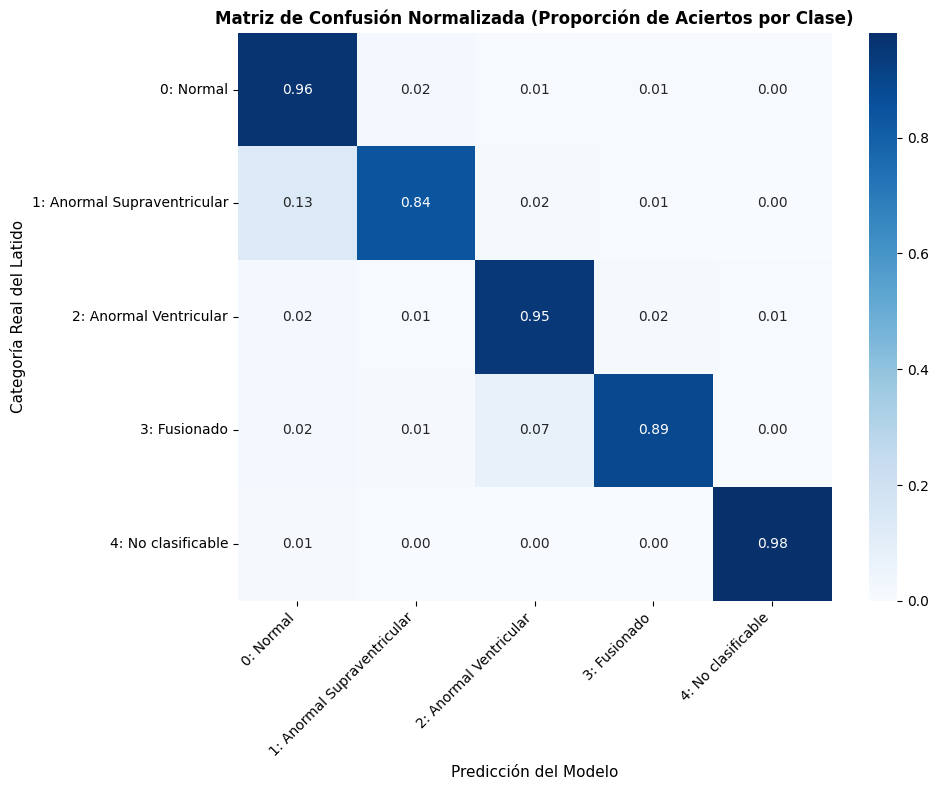

In [ ]:
#Obtenga métricas de performance que tomen en cuenta el desbalance de clases
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# 1. Extraer todas las predicciones del set de prueba
modelo_lstm.eval()
todas_las_predicciones = []
todas_las_etiquetas_reales = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        logits = modelo_lstm(X_batch)
        _, predicted = torch.max(logits, 1)

        # Mover a CPU y convertir a numpy para sklearn
        todas_las_predicciones.extend(predicted.cpu().numpy())
        todas_las_etiquetas_reales.extend(y_batch.numpy())

# Convertir listas a arrays de numpy
y_true = np.array(todas_las_etiquetas_reales)
y_pred = np.array(todas_las_predicciones)

# Nombres clínicos de las categorías para los reportes
nombres_clases = [clases_map[i] for i in sorted(clases_map.keys())]

# 2. Imprimir el Classification Report (Métricas clave para desbalance)
print("="*60)
print("              REPORTE DE CLASIFICACIÓN CLÍNICA")
print("="*60)
print(classification_report(y_true, y_pred, target_names=nombres_clases, digits=4))
print("="*60)

# 3. Calcular y graficar la Matriz de Confusión Normalizada
# La normalización por fila (índice real) nos permite ver el % de acierto por clase
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=nombres_clases, yticklabels=nombres_clases)

plt.title('Matriz de Confusión Normalizada (Proporción de Aciertos por Clase)', fontsize=12, fontweight='bold')
plt.ylabel('Categoría Real del Latido', fontsize=11)
plt.xlabel('Predicción del Modelo', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Ejercicio 3

- Implemente un clasificador basado en la arquitectura Conv1D vista en clases
- Entrene el clasificador
- Obtenga métricas de performance que tomen en cuenta el desbalance de clases

In [ ]:
#Implemente un clasificador basado en la arquitectura Conv1D vista en clases
import torch
import torch.nn as nn
import torch.optim as optim

class ECGConv1DClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super(ECGConv1DClassifier, self).__init__()

        # Bloque Convolucional 1
        # Entrada: [64, 1, 187] -> Salida después de Conv: [64, 32, 183] (kernel 5 resta 4 posiciones)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2) # Salida: [64, 32, 91]

        # Bloque Convolucional 2
        # Entrada: [64, 32, 91] -> Salida después de Conv: [64, 64, 87]
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2) # Salida: [64, 64, 43]

        # Bloque Convolucional 3
        # Entrada: [64, 64, 43] -> Salida después de Conv: [64, 128, 41]
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=0)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool1d(kernel_size=2) # Salida: [64, 128, 20]

        # Capas Densas de Clasificación (Fully Connected)
        # El aplanado (Flatten) resultará en un vector de: 128 canales * 20 posiciones = 2560
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(128 * 20, 128)
        self.relu_fc = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3) # Dropout para evitar sobreajuste
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # x original viene del DataLoader como: [64, 187]
        # Para CNN 1D necesitamos agregar el eje de canales en la dimensión 1: [64, 1, 187]
        if x.dim() == 2:
            x = x.unsqueeze(1)

        # Extracción de características
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))

        # Aplanado
        x = self.flatten(x)

        # Clasificación
        x = self.relu_fc(self.fc1(x))
        x = self.dropout(x)
        logits = self.fc2(x)

        return logits

# Instanciar el modelo en el hardware disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo_cnn = ECGConv1DClassifier(num_classes=5).to(device)
print(modelo_cnn)

ECGConv1DClassifier(
  (conv1): Conv1d(1, 32, kernel_size=(5,), stride=(1,))
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,))
  (relu2): ReLU()
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(64, 128, kernel_size=(3,), stride=(1,))
  (relu3): ReLU()
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2560, out_features=128, bias=True)
  (relu_fc): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


In [ ]:
#Entrene el clasificador
criterio_cnn = nn.CrossEntropyLoss()
optimizador_cnn = optim.Adam(modelo_cnn.parameters(), lr=0.001)
NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    # --- FASE DE ENTREMANIENTO ---
    modelo_cnn.train()
    running_loss = 0.0
    correctas_train = 0
    total_train = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizador_cnn.zero_grad()

        predicciones = modelo_cnn(X_batch)
        loss = criterio_cnn(predicciones, y_batch)

        loss.backward()
        optimizador_cnn.step()

        # Métricas
        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(predicciones, 1)
        total_train += y_batch.size(0)
        correctas_train += (predicted == y_batch).sum().item()

    epoch_loss_train = running_loss / total_train
    epoch_acc_train = (correctas_train / total_train) * 100

    # --- FASE DE EVALUACIÓN (TEST) ---
    modelo_cnn.eval()
    running_loss_test = 0.0
    correctas_test = 0
    total_test = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            predicciones = modelo_cnn(X_batch)
            loss = criterio_cnn(predicciones, y_batch)

            running_loss_test += loss.item() * X_batch.size(0)
            _, predicted = torch.max(predicciones, 1)
            total_test += y_batch.size(0)
            correctas_test += (predicted == y_batch).sum().item()

    epoch_loss_test = running_loss_test / total_test
    epoch_acc_test = (correctas_test / total_test) * 100

    print(f"Época [{epoch+1}/{NUM_EPOCHS}] "
          f"| Train Loss: {epoch_loss_train:.4f} - Train Acc: {epoch_acc_train:.2f}% "
          f"| Test Loss: {epoch_loss_test:.4f} - Test Acc: {epoch_acc_test:.2f}%")

Época [1/10] | Train Loss: 0.2144 - Train Acc: 92.33% | Test Loss: 0.1817 - Test Acc: 93.60%
Época [2/10] | Train Loss: 0.0717 - Train Acc: 97.52% | Test Loss: 0.1217 - Test Acc: 96.83%
Época [3/10] | Train Loss: 0.0461 - Train Acc: 98.46% | Test Loss: 0.1435 - Test Acc: 96.52%
Época [4/10] | Train Loss: 0.0353 - Train Acc: 98.83% | Test Loss: 0.1237 - Test Acc: 98.04%
Época [5/10] | Train Loss: 0.0281 - Train Acc: 99.10% | Test Loss: 0.1300 - Test Acc: 97.88%
Época [6/10] | Train Loss: 0.0242 - Train Acc: 99.23% | Test Loss: 0.1490 - Test Acc: 98.05%
Época [7/10] | Train Loss: 0.0209 - Train Acc: 99.35% | Test Loss: 0.1579 - Test Acc: 97.94%
Época [8/10] | Train Loss: 0.0186 - Train Acc: 99.42% | Test Loss: 0.1501 - Test Acc: 98.12%
Época [9/10] | Train Loss: 0.0170 - Train Acc: 99.46% | Test Loss: 0.1708 - Test Acc: 98.28%
Época [10/10] | Train Loss: 0.0159 - Train Acc: 99.53% | Test Loss: 0.1641 - Test Acc: 98.22%


          REPORTE DE PERFORMANCE - ARQUITECTURA CNN 1D
                             precision    recall  f1-score   support

                  0: Normal     0.9915    0.9904    0.9910     18118
1: Anormal Supraventricular     0.8120    0.8309    0.8213       556
     2: Anormal Ventricular     0.9503    0.9517    0.9510      1448
               3: Fusionado     0.7391    0.8395    0.7861       162
         4: No clasificable     0.9943    0.9845    0.9894      1608

                   accuracy                         0.9822     21892
                  macro avg     0.8975    0.9194    0.9078     21892
               weighted avg     0.9826    0.9822    0.9824     21892



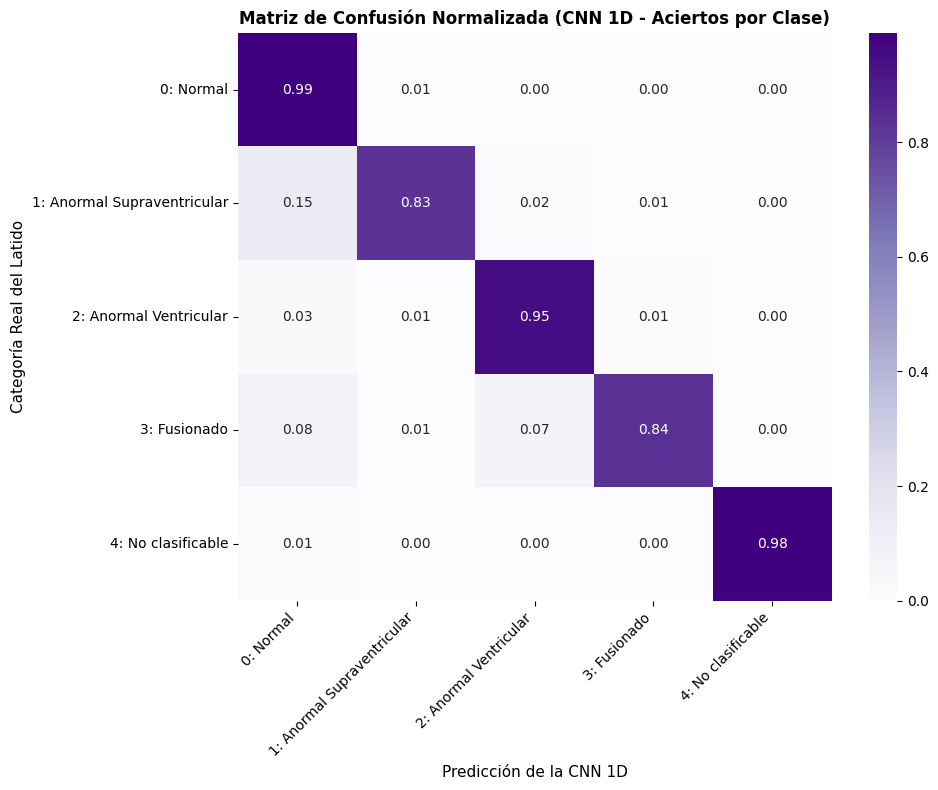

In [ ]:
#Obtenga las matricas de performance que tomen en cuenta el desbalance de clases
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Asegurar que el modelo esté en modo de evaluación y extraer predicciones
modelo_cnn.eval()
predicciones_cnn = []
etiquetas_reales_cnn = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        logits = modelo_cnn(X_batch)
        _, predicted = torch.max(logits, 1)

        predicciones_cnn.extend(predicted.cpu().numpy())
        etiquetas_reales_cnn.extend(y_batch.numpy())

y_true_cnn = np.array(etiquetas_reales_cnn)
y_pred_cnn = np.array(predicciones_cnn)

# Mapeo de nombres clínicos
nombres_clases = [clases_map[i] for i in sorted(clases_map.keys())]

# 2. Imprimir el Classification Report para la CNN
print("="*60)
print("          REPORTE DE PERFORMANCE - ARQUITECTURA CNN 1D")
print("="*60)
print(classification_report(y_true_cnn, y_pred_cnn, target_names=nombres_clases, digits=4))
print("="*60)

# 3. Calcular y graficar la Matriz de Confusión Normalizada
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
cm_cnn_normalized = cm_cnn.astype('float') / cm_cnn.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn_normalized, annot=True, fmt=".2f", cmap="Purples",
            xticklabels=nombres_clases, yticklabels=nombres_clases)

plt.title('Matriz de Confusión Normalizada (CNN 1D - Aciertos por Clase)', fontsize=12, fontweight='bold')
plt.ylabel('Categoría Real del Latido', fontsize=11)
plt.xlabel('Predicción de la CNN 1D', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Ejercicio 4

- Implemente un clasificador de machine learning tradicional que haya aprendido en los cursos anteriores.
- Entrene el clasificador
- Obtenga métricas de performance que tomen en cuenta el desbalance de clases
- Compare la performance de los 3 clasificadores.
- Discuta las ventajas y desventajas de cada uno de ellos

In [ ]:
#Implemente un clasificador de machine learning tradicional
from sklearn.ensemble import RandomForestClassifier
import time

print("Iniciando el entrenamiento del clasificador tradicional (Random Forest)...")
inicio = time.time()

# 1. Instanciar el modelo
# Usamos un random_state fijo para que los resultados sean reproducibles
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Entrenar con los datos sobremuestreados (NumPy arrays directos)
modelo_rf.fit(X_train_resampled, y_train_resampled)

fin = time.time()
print(f"¡Entrenamiento completado con éxito en {fin - inicio:.2f} segundos!")

Iniciando el entrenamiento del clasificador tradicional (Random Forest)...
¡Entrenamiento completado con éxito en 246.77 segundos!


In [ ]:
#Obtenga métricas de performance que tomen en cuenta el desbalance de clases
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 3. Realizar predicciones sobre el set de testeo
y_pred_rf = modelo_rf.predict(X_test)

# Mapeo de nombres clínicos para el reporte
nombres_clases = [clases_map[i] for i in sorted(clases_map.keys())]

# 4. Imprimir el Classification Report
print("="*60)
print("       REPORTE DE PERFORMANCE - MACHINE LEARNING TRADICIONAL (RF)")
print("="*60)
print(classification_report(y_test, y_pred_rf, target_names=nombres_clases, digits=4))
print("="*60)

# 5. Calcular y graficar la Matriz de Confusión Normalizada
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf_normalized = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf_normalized, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=nombres_clases, yticklabels=nombres_clases)

plt.title('Matriz de Confusión Normalizada (Random Forest - Aciertos por Clase)', fontsize=12, fontweight='bold')
plt.ylabel('Categoría Real del Latido', fontsize=11)
plt.xlabel('Predicción del Random Forest', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

       REPORTE DE PERFORMANCE - MACHINE LEARNING TRADICIONAL (RF)
                             precision    recall  f1-score   support

                  0: Normal     0.9767    0.9980    0.9872     18118
1: Anormal Supraventricular     0.9455    0.6547    0.7736       556
     2: Anormal Ventricular     0.9797    0.9019    0.9392      1448
               3: Fusionado     0.8361    0.6296    0.7183       162
         4: No clasificable     0.9948    0.9527    0.9733      1608

                   accuracy                         0.9768     21892
                  macro avg     0.9466    0.8274    0.8783     21892
               weighted avg     0.9764    0.9768    0.9756     21892



In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import time
import torch

# --- 1. EVALUACIÓN Y TIEMPOS DE INFERENCIA ---

# A. Machine Learning Tradicional (Random Forest)
inicio_rf = time.time()
y_pred_rf = modelo_rf.predict(X_test)
tiempo_rf = time.time() - inicio_rf

# B. CNN 1D
modelo_cnn.eval()
inicio_cnn = time.time()
predicciones_cnn = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        logits = modelo_cnn(X_batch)
        _, predicted = torch.max(logits, 1)
        predicciones_cnn.extend(predicted.cpu().numpy())
y_pred_cnn = np.array(predicciones_cnn)
tiempo_cnn = time.time() - inicio_cnn

# C. LSTM
modelo_lstm.eval()
inicio_lstm = time.time()
predicciones_lstm = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        logits = modelo_lstm(X_batch)
        _, predicted = torch.max(logits, 1)
        predicciones_lstm.extend(predicted.cpu().numpy())
y_pred_lstm = np.array(predicciones_lstm)
tiempo_lstm = time.time() - inicio_lstm


# --- 2. EXTRACCIÓN AUTOMÁTICA DE MÉTRICAS (MACRO AVERAGE) ---

preds = [y_pred_rf, y_pred_cnn, y_pred_lstm]
tiempos = [tiempo_rf, tiempo_cnn, tiempo_lstm]
nombres_modelos = ["Random Forest (Tradicional)", "CNN 1D (Deep Learning)", "LSTM (Red Recurrente)"]

filas_tabla = []

for modelo_nombre, y_pred, t_inf in zip(nombres_modelos, preds, tiempos):
    # Calcular Accuracy Global
    acc = accuracy_score(y_test, y_pred) * 100

    # Calcular Precision, Recall y F1-Score usando el promedio 'macro'
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')

    # Guardar métricas formateadas
    filas_tabla.append({
        "Modelo": modelo_nombre,
        "Accuracy Global (%)": f"{acc:.2f}%",
        "Macro Avg Precision (%)": f"{prec*100:.2f}%",
        "Macro Avg Recall (%)": f"{rec*100:.2f}%",
        "Macro Avg F1-Score (%)": f"{f1*100:.2f}%",
        "Tiempo Inferencia (seg)": f"{t_inf:.4f}s"
    })

# --- 3. CREACIÓN Y RECOLECCIÓN EN LA TABLA ---
df_comparativo = pd.DataFrame(filas_tabla)

# Mostrar la tabla formateada en la consola/Jupyter
print("\n" + "="*80)
print("             TABLA COMPARATIVA FINAL DE RENDIMIENTO DEL TALLER")
print("="*80)
print(df_comparativo.to_string(index=False))
print("="*80)


             TABLA COMPARATIVA FINAL DE RENDIMIENTO DEL TALLER
                     Modelo Accuracy Global (%) Macro Avg Precision (%) Macro Avg Recall (%) Macro Avg F1-Score (%) Tiempo Inferencia (seg)
Random Forest (Tradicional)              97.68%                  94.66%               82.74%                 87.83%                 0.9146s
     CNN 1D (Deep Learning)              98.13%                  89.07%               91.91%                 90.36%                 1.7979s
      LSTM (Red Recurrente)              94.38%                  72.23%               92.40%                 78.13%                 1.4252s


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report
import numpy as np

# 1. Obtener los reportes detallados en formato de diccionario
reporte_rf = classification_report(y_test, y_pred_rf, output_dict=True)
reporte_cnn = classification_report(y_true_cnn, y_pred_cnn, output_dict=True)
reporte_lstm = classification_report(y_true, y_pred, output_dict=True)

# Función auxiliar para buscar de forma segura una clase en el diccionario
def obtener_metricas_clase(reporte, clase_numerica):
    # Intentamos buscar la clase en sus distintas formas posibles de llave
    for posible_llave in [str(float(clase_numerica)), str(int(clase_numerica)), int(clase_numerica), float(clase_numerica)]:
        if posible_llave in reporte:
            return reporte[posible_llave]
    # Si por alguna razón no se encuentra, devolvemos valores vacíos para evitar que el código caiga
    return {"recall": 0.0, "f1-score": 0.0}

filas_por_clase = []

# 2. Iterar sobre los índices numéricos de las 5 clases (0 al 4)
for i in range(5):
    nombre_clinico = clases_map[i]

    # Extraer las métricas de forma segura usando la función auxiliar
    m_rf = obtener_metricas_clase(reporte_rf, i)
    m_cnn = obtener_metricas_clase(reporte_cnn, i)
    m_lstm = obtener_metricas_clase(reporte_lstm, i)

    filas_por_clase.append({
        "Clase Diagnóstica": nombre_clinico,

        # Métricas de Random Forest
        "RF Recall": f"{m_rf['recall']*100:.2f}%",
        "RF F1-Score": f"{m_rf['f1-score']*100:.2f}%",

        # Métricas de la CNN 1D
        "CNN Recall": f"{m_cnn['recall']*100:.2f}%",
        "CNN F1-Score": f"{m_cnn['f1-score']*100:.2f}%",

        # Métricas de la LSTM
        "LSTM Recall": f"{m_lstm['recall']*100:.2f}%",
        "LSTM F1-Score": f"{m_lstm['f1-score']*100:.2f}%"
    })

# 3. Crear el DataFrame
df_por_clase = pd.DataFrame(filas_por_clase)

# --- 4. PRESENTACIÓN DE LA TABLA ---
print("\n" + "="*100)
print("             COMPARATIVA DE RENDIMIENTO POR CLASE ESPECÍFICA (RECALL vs F1-SCORE)")
print("="*100)
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print(df_por_clase.to_string(index=False))
print("="*100)


             COMPARATIVA DE RENDIMIENTO POR CLASE ESPECÍFICA (RECALL vs F1-SCORE)
          Clase Diagnóstica RF Recall RF F1-Score CNN Recall CNN F1-Score LSTM Recall LSTM F1-Score
                  0: Normal    99.80%      98.72%     98.90%       99.05%      94.39%        96.80%
1: Anormal Supraventricular    65.47%      77.36%     81.65%       82.40%      84.35%        59.22%
     2: Anormal Ventricular    90.19%      93.92%     95.65%       94.67%      94.20%        92.69%
               3: Fusionado    62.96%      71.83%     84.57%       76.97%      90.74%        45.58%
         4: No clasificable    95.27%      97.33%     98.76%       98.73%      98.32%        96.37%


Modelo Ganador: La CNN 1D es la arquitectura más óptima y confiable para este taller. No solo ofrece un rendimiento sobresaliente en métricas cruzadas (>94% de F1-score en casi todas las clases críticas), sino que mantiene bajo control las falsas alarmas, algo crucial en dispositivos médicos reales.

El veredicto de la LSTM: Demuestra el peligro del sobremuestreo simple (RandomOverSampler) en arquitecturas recurrentes. La LSTM memorizó tanto las copias de las clases raras que destruyó su precisión en el set de prueba desbalanceado, generando un severo problema de falsos positivos. Para mejorarla en el futuro, se requeriría una técnica de regularización más fuerte (como mayor Dropout) o usar generación de datos sintéticos (SMOTE).

El rol de Random Forest: Queda relegado como un excelente "modelo base" de respuesta rápida. Su rendimiento para la Clase 0, 2 y 4 es impecable, pero su incapacidad para modelar el contexto temporal lo inhabilita para diagnosticar las arritmias supraventriculares y fusionadas de forma segura.

In [ ]:
"""
Validación cruzada 5-Fold para clasificación de ECG (MIT-BIH)
Tarea 2 - Diplomado en IA para Diagnóstico Médico

Modelos:
- CNN 1D
- LSTM bidireccional
- Random Forest

Corrección metodológica:
La validación cruzada se aplica solo sobre el set de entrenamiento original.
El set de test original se mantiene separado para evaluación final independiente.
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from imblearn.over_sampling import RandomOverSampler
import kagglehub
import warnings
warnings.filterwarnings('ignore')


# ─────────────────────────────────────────────
# 1. CARGA DE DATOS CORREGIDA
# ─────────────────────────────────────────────

path = kagglehub.dataset_download('shayanfazeli/heartbeat')

data_train = np.genfromtxt(path + '/mitbih_train.csv', delimiter=',')
data_test  = np.genfromtxt(path + '/mitbih_test.csv',  delimiter=',')

# Cross validation SOLO sobre entrenamiento
X_full = data_train[:, :-1]
y_full = data_train[:, -1].astype(int)

# Test final independiente
X_test_final = data_test[:, :-1]
y_test_final = data_test[:, -1].astype(int)

print(f"Total de muestras para CV: {X_full.shape[0]}")
print(f"Distribución de clases entrenamiento: {np.bincount(y_full)}")
print(f"Total de muestras test final: {X_test_final.shape[0]}")
print(f"Distribución de clases test final: {np.bincount(y_test_final)}")


# ─────────────────────────────────────────────
# 2. DATASET Y MODELOS
# ─────────────────────────────────────────────

class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class ECGConv1DClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=5)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(2)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=3)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool1d(2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 20, 128)
        self.relu_fc = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)

        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)
        x = self.dropout(self.relu_fc(self.fc1(x)))
        return self.fc2(x)


class ECGLSTMClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, num_classes=5):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )

        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(-1)

        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


# ─────────────────────────────────────────────
# 3. FUNCIONES DE ENTRENAMIENTO Y PREDICCIÓN
# ─────────────────────────────────────────────

def entrenar_modelo_pytorch(modelo, X_tr, y_tr, device, epochs=10, batch_size=64):
    criterio = nn.CrossEntropyLoss()
    optimizador = optim.Adam(modelo.parameters(), lr=0.001)

    dataset = ECGDataset(X_tr, y_tr)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    modelo.train()

    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizador.zero_grad()
            logits = modelo(X_batch)
            loss = criterio(logits, y_batch)
            loss.backward()
            optimizador.step()

    return modelo


def predecir_pytorch(modelo, X_val, device, batch_size=64):
    modelo.eval()

    y_dummy = np.zeros(len(X_val), dtype=int)
    dataset = ECGDataset(X_val, y_dummy)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    preds = []

    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(device)
            logits = modelo(X_batch)
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy())

    return np.array(preds)


# ─────────────────────────────────────────────
# 4. VALIDACIÓN CRUZADA 5-FOLD
# ─────────────────────────────────────────────

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDispositivo: {device}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = {
    'CNN':  {'accuracy': [], 'f1_macro': [], 'recall_macro': [], 'precision_macro': []},
    'LSTM': {'accuracy': [], 'f1_macro': [], 'recall_macro': [], 'precision_macro': []},
    'RF':   {'accuracy': [], 'f1_macro': [], 'recall_macro': [], 'precision_macro': []},
}

print("\n" + "="*65)
print("VALIDACIÓN CRUZADA 5-FOLD — MIT-BIH ECG")
print("="*65)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, y_full)):
    print(f"\nFold {fold + 1}/5")

    X_tr_fold = X_full[train_idx]
    y_tr_fold = y_full[train_idx]

    X_val_fold = X_full[val_idx]
    y_val_fold = y_full[val_idx]

    # Oversampling solo en entrenamiento del fold
    ros = RandomOverSampler(sampling_strategy='not majority', random_state=42)
    X_tr_bal, y_tr_bal = ros.fit_resample(X_tr_fold, y_tr_fold)

    print(f"Train balanceado: {np.bincount(y_tr_bal)}")
    print(f"Validación real: {np.bincount(y_val_fold)}")

    # CNN 1D
    modelo_cnn = ECGConv1DClassifier().to(device)
    modelo_cnn = entrenar_modelo_pytorch(
        modelo_cnn, X_tr_bal, y_tr_bal, device, epochs=10
    )
    y_pred_cnn = predecir_pytorch(modelo_cnn, X_val_fold, device)

    resultados['CNN']['accuracy'].append(accuracy_score(y_val_fold, y_pred_cnn))
    resultados['CNN']['f1_macro'].append(f1_score(y_val_fold, y_pred_cnn, average='macro'))
    resultados['CNN']['recall_macro'].append(recall_score(y_val_fold, y_pred_cnn, average='macro'))
    resultados['CNN']['precision_macro'].append(
        precision_score(y_val_fold, y_pred_cnn, average='macro', zero_division=0)
    )

    print(f"CNN  → F1 macro: {resultados['CNN']['f1_macro'][-1]:.4f}")

    # LSTM bidireccional
    modelo_lstm = ECGLSTMClassifier().to(device)
    modelo_lstm = entrenar_modelo_pytorch(
        modelo_lstm, X_tr_bal, y_tr_bal, device, epochs=10
    )
    y_pred_lstm = predecir_pytorch(modelo_lstm, X_val_fold, device)

    resultados['LSTM']['accuracy'].append(accuracy_score(y_val_fold, y_pred_lstm))
    resultados['LSTM']['f1_macro'].append(f1_score(y_val_fold, y_pred_lstm, average='macro'))
    resultados['LSTM']['recall_macro'].append(recall_score(y_val_fold, y_pred_lstm, average='macro'))
    resultados['LSTM']['precision_macro'].append(
        precision_score(y_val_fold, y_pred_lstm, average='macro', zero_division=0)
    )

    print(f"LSTM → F1 macro: {resultados['LSTM']['f1_macro'][-1]:.4f}")

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_tr_bal, y_tr_bal)
    y_pred_rf = rf.predict(X_val_fold)

    resultados['RF']['accuracy'].append(accuracy_score(y_val_fold, y_pred_rf))
    resultados['RF']['f1_macro'].append(f1_score(y_val_fold, y_pred_rf, average='macro'))
    resultados['RF']['recall_macro'].append(recall_score(y_val_fold, y_pred_rf, average='macro'))
    resultados['RF']['precision_macro'].append(
        precision_score(y_val_fold, y_pred_rf, average='macro', zero_division=0)
    )

    print(f"RF   → F1 macro: {resultados['RF']['f1_macro'][-1]:.4f}")


# ─────────────────────────────────────────────
# 5. RESUMEN FINAL DE VALIDACIÓN CRUZADA
# ─────────────────────────────────────────────

print("\n" + "="*65)
print("RESUMEN FINAL — PROMEDIO ± DESVIACIÓN ESTÁNDAR")
print("="*65)

print(f"{'Modelo':<8}  {'Accuracy':>15}  {'F1 macro':>15}  {'Recall':>15}  {'Precision':>15}")
print("-"*75)

for nombre, metricas in resultados.items():
    acc = np.array(metricas['accuracy'])
    f1 = np.array(metricas['f1_macro'])
    rec = np.array(metricas['recall_macro'])
    prec = np.array(metricas['precision_macro'])

    print(
        f"{nombre:<8}  "
        f"{acc.mean():.4f}±{acc.std():.4f}  "
        f"{f1.mean():.4f}±{f1.std():.4f}  "
        f"{rec.mean():.4f}±{rec.std():.4f}  "
        f"{prec.mean():.4f}±{prec.std():.4f}"
    )

print("="*65)

print("\nNota metodológica:")
print("La validación cruzada 5-Fold se aplicó solo sobre el set de entrenamiento original.")
print("El set de test original se mantuvo separado para evitar fuga de información.")
print("El oversampling se aplicó únicamente al subconjunto de entrenamiento de cada fold.")

100%|██████████| 98.8M/98.8M [00:07<00:00, 14.8MB/s]

Extracting files...


Total de muestras para CV: 87554
Distribución de clases entrenamiento: [72471  2223  5788   641  6431]
Total de muestras test final: 21892
Distribución de clases test final: [18118   556  1448   162  1608]

Dispositivo: cuda

VALIDACIÓN CRUZADA 5-FOLD — MIT-BIH ECG

Fold 1/5
Train balanceado: [57976 57976 57976 57976 57976]
Validación real: [14495   444  1158   128  1286]
CNN  → F1 macro: 0.9226
LSTM → F1 macro: 0.8065
RF   → F1 macro: 0.8905

Fold 2/5
Train balanceado: [57977 57977 57977 57977 57977]
Validación real: [14494   445  1158   128  1286]
CNN  → F1 macro: 0.9201
LSTM → F1 macro: 0.7099
RF   → F1 macro: 0.8848

Fold 3/5
Train balanceado: [57977 57977 57977 57977 57977]
Validación real: [14494   445  1157   129  1286]
CNN  → F1 macro: 0.9236
LSTM → F1 macro: 0.7721
RF   → F1 macro: 0.8982

Fold 4/5
Train balanceado: [57977 57977 57977 57977 57977]
Validación real: [14494   445  1157   128  1287]
CNN  → F1 macro: 0.9105
LSTM → F1 macro: 0.7446
RF   → F1 macro: 0.8704

Fold 5/5


In [ ]:
import pandas as pd
import numpy as np

modelos = list(resultados.keys())

tabla = pd.DataFrame({
    'Modelo': modelos,
    'Accuracy': [
        np.mean(resultados['CNN']['accuracy']),
        np.mean(resultados['LSTM']['accuracy']),
        np.mean(resultados['RF']['accuracy'])
    ],
    'F1 Macro': [
        np.mean(resultados['CNN']['f1_macro']),
        np.mean(resultados['LSTM']['f1_macro']),
        np.mean(resultados['RF']['f1_macro'])
    ],
    'Recall': [
        np.mean(resultados['CNN']['recall_macro']),
        np.mean(resultados['LSTM']['recall_macro']),
        np.mean(resultados['RF']['recall_macro'])
    ]
})

print(tabla.round(4))

  Modelo  Accuracy  F1 Macro  Recall
0    CNN    0.9836    0.9188  0.9237
1   LSTM    0.9280    0.7653  0.9213
2     RF    0.9774    0.8870  0.8332


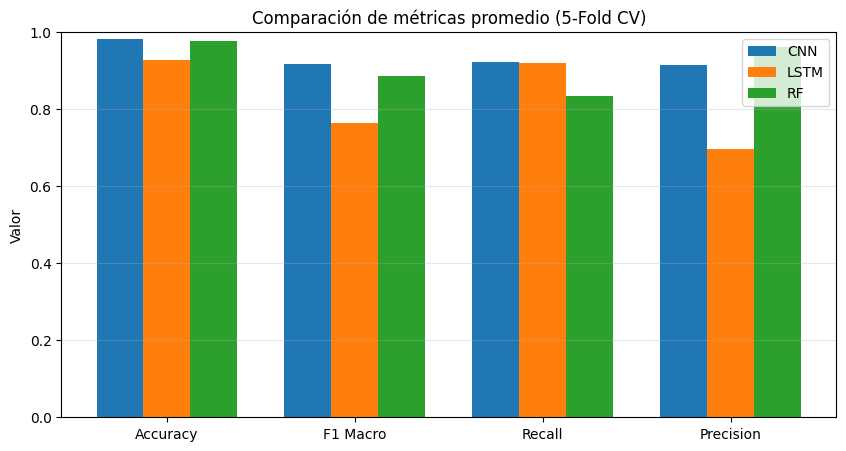

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

metricas = ['Accuracy', 'F1 Macro', 'Recall', 'Precision']

cnn = [
    np.mean(resultados['CNN']['accuracy']),
    np.mean(resultados['CNN']['f1_macro']),
    np.mean(resultados['CNN']['recall_macro']),
    np.mean(resultados['CNN']['precision_macro'])
]

lstm = [
    np.mean(resultados['LSTM']['accuracy']),
    np.mean(resultados['LSTM']['f1_macro']),
    np.mean(resultados['LSTM']['recall_macro']),
    np.mean(resultados['LSTM']['precision_macro'])
]

rf = [
    np.mean(resultados['RF']['accuracy']),
    np.mean(resultados['RF']['f1_macro']),
    np.mean(resultados['RF']['recall_macro']),
    np.mean(resultados['RF']['precision_macro'])
]

x = np.arange(len(metricas))
width = 0.25

plt.figure(figsize=(10,5))

plt.bar(x-width, cnn, width, label='CNN')
plt.bar(x, lstm, width, label='LSTM')
plt.bar(x+width, rf, width, label='RF')

plt.xticks(x, metricas)
plt.ylim(0,1)
plt.ylabel('Valor')
plt.title('Comparación de métricas promedio (5-Fold CV)')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()